2026-07-30 11:28:26,517 [INFO] Tạo nhãn Target với khoảng thời gian dự phóng (horizon) = 1 phiên...
2026-07-30 11:28:26,593 [INFO] Đang tính toán mức độ quan trọng của đặc trưng bằng Random Forest...


Kích thước dữ liệu đầu vào: (2142, 19)
Phân phối nhãn Target (0: Giảm, 1: Tăng):
Target
0    1358
1     783
Name: count, dtype: int64


2026-07-30 11:28:27,646 [INFO] Top 10 features được chọn: ['CMF', 'ROC', 'ATR', 'ADX', 'Stoch_k', 'MACD', 'MACD_Signal', 'RSI_14', 'OBV', 'SMA_50']



=== TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT ===
CMF            0.088595
ROC            0.085940
ATR            0.077388
ADX            0.077281
Stoch_k        0.077103
MACD           0.074613
MACD_Signal    0.074379
RSI_14         0.069865
OBV            0.066360
SMA_50         0.063988
dtype: float64


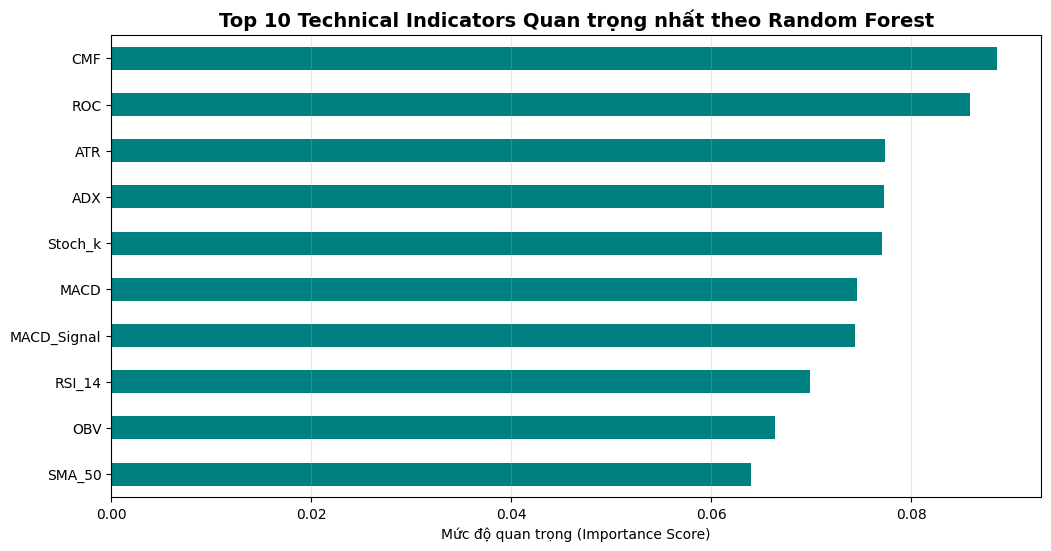


Đã lưu bộ dữ liệu chuẩn hóa AI tại: ../data/processed/AAPL_ml_ready.parquet
Kích thước DataFrame sẵn sàng huấn luyện: (2141, 12)


In [1]:
# Cell 1: Import và Nạp dữ liệu Features
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
from utils.feature_selector import FeatureSelector

# Tự động reload code
%load_ext autoreload
%autoreload 2

# Nạp dữ liệu từ Notebook 05
df_features = pd.read_parquet("../data/processed/AAPL_features.parquet")
print("Kích thước dữ liệu đầu vào:", df_features.shape)

# Cell 2: Tạo Nhãn (Target)
fs = FeatureSelector(df_features)
df_labeled = fs.create_target(horizon=1, threshold=0.0)

print(f"Phân phối nhãn Target (0: Giảm, 1: Tăng):\n{df_labeled['Target'].value_counts()}")

# Cell 3: Chạy Lựa chọn Đặc trưng bằng Random Forest
top_features, importances = fs.select_features_by_rf(top_n=10)

# In kết quả xếp hạng
print("\n=== TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT ===")
print(importances.head(10))

# Cell 4: Trực quan hóa Biểu đồ Feature Importance
plt.figure(figsize=(12, 6))
importances.head(10).sort_values().plot(kind='barh', color='teal')
plt.title("Top 10 Technical Indicators Quan trọng nhất theo Random Forest", fontsize=14, fontweight="bold")
plt.xlabel("Mức độ quan trọng (Importance Score)")
plt.grid(True, axis='x', alpha=0.3)
plt.show()

# Cell 5: Lưu tập dữ liệu hoàn thiện cuối cùng cho Machine Learning
# Giữ lại các Top Features + Target + Các cột giá cơ bản phục vụ tính toán Backtest sau này
final_cols = top_features + ['Close', 'Target']
df_final = df_labeled[final_cols]

output_path = "../data/processed/AAPL_ml_ready.parquet"
df_final.to_parquet(output_path)
print(f"\nĐã lưu bộ dữ liệu chuẩn hóa AI tại: {output_path}")
print(f"Kích thước DataFrame sẵn sàng huấn luyện: {df_final.shape}")